# Gibbs Sampler

We shall look at how the Gibbs sampler works in some simple examples. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Example One: Bivariate Normal

Below we use the Gibbs sampler to generate samples from the bivariate normal distribution with mean $(y_1, y_2) = (0, 0)$, variances equal to 1 and correlation equal to $\rho$. The main message here is that Gibbs sampler works well unless $|\rho|$ is very close to one. 

In [2]:
y1, y2 = 0, 0
rho  = 0.8
#rho = 0.9999 #this is the correlation between the two variables
state = np.array([0.0, 0.0], dtype = float) #this is the initial state
nit = 100000 #number of iterations for the Gibbs sampler

path = np.zeros((nit, 2))
path[0] = state

sd = np.sqrt(1 - rho**2) #this is the standard deviation of the conditional distribution

for t in range(1, nit):
    j = np.random.randint(2)
    if j == 0:
        path[t, 0] = y1 + rho * (state[1] - y2) + sd * np.random.randn()
        path[t, 1] = state[1]
    else:
        path[t, 0] = state[0]
        path[t, 1] = y2 + rho * (state[0] - y1) + sd * np.random.randn()
    state = path[t]

print(path[:8]) #first 8 samples from the Gibbs sampler
print(path[-8:]) #last 8 samples from the Gibbs sampler

[[ 0.          0.        ]
 [ 0.26701711  0.        ]
 [ 0.26701711 -0.04823402]
 [-0.62608421 -0.04823402]
 [-0.02868506 -0.04823402]
 [-0.02868506  0.48592908]
 [ 0.68945986  0.48592908]
 [ 0.558989    0.48592908]]
[[ 0.74211327  0.70611718]
 [ 0.85254828  0.70611718]
 [ 0.85254828  0.42511837]
 [ 0.12599002  0.42511837]
 [ 0.12599002 -0.87818479]
 [ 0.12599002 -0.74251421]
 [ 0.55479287 -0.74251421]
 [ 0.55479287 -0.41308702]]


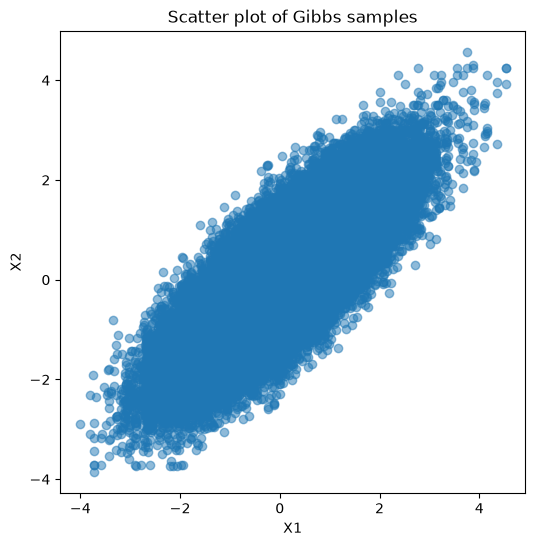

In [3]:
plt.figure(figsize=(6, 6))
plt.scatter(path[:, 0], path[:, 1], alpha=0.5)
plt.title("Scatter plot of Gibbs samples")
plt.xlabel("X1")
plt.ylabel("X2")
plt.axis("equal")
plt.show()

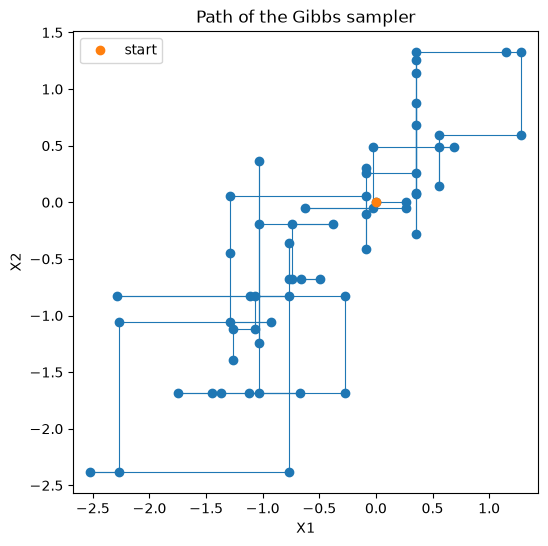

In [4]:
plt.figure(figsize=(6, 6))
nplot = 60
plt.plot(path[:nplot, 0], path[:nplot, 1], "-o", lw=0.8)   # path of the chain
plt.plot(path[0, 0], path[0, 1], "o", label="start")   # starting point
plt.title("Path of the Gibbs sampler")
plt.xlabel("X1")
plt.ylabel("X2")
plt.axis("equal")
plt.legend()
plt.show()

Below we plot the trace plots for each of the two variables $X_1$ and $X_2$. The trace plot for $X_1$ is the plot of $X_1^{(t)}$ versus $t$ and the trace plot for $X_2$ is the plot of $X_2^{(t)}$ versus $t$. One uses these to check if the Markov chain has mixed properly.

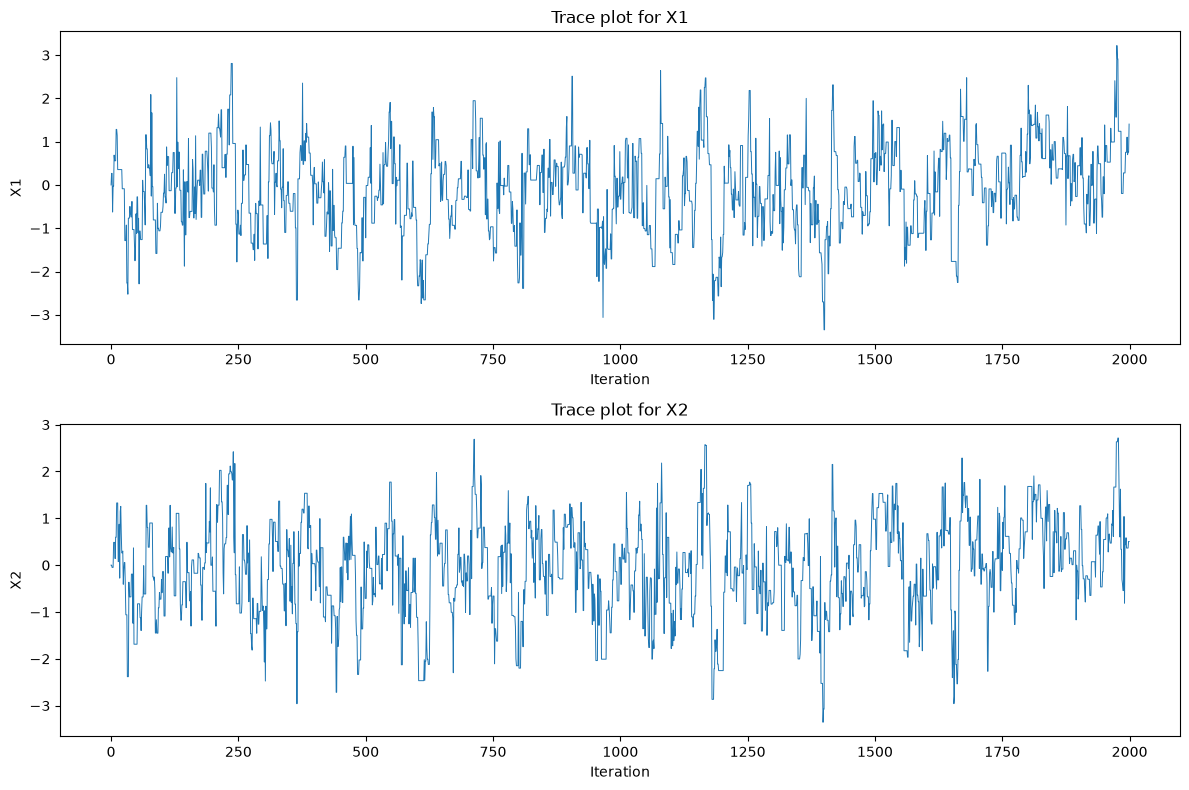

In [5]:
#Plotting the marginal distributions: 
xx = np.linspace(-4, 4, 400)
dnorm = (1 / np.sqrt(2 * np.pi)) * np.exp(-xx**2 / 2)

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(path[:2000, 0], lw=0.7)
plt.title("Trace plot for X1")
plt.xlabel("Iteration")
plt.ylabel("X1")

plt.subplot(2, 1, 2)
plt.plot(path[:2000, 1], lw=0.7)
plt.title("Trace plot for X2")
plt.xlabel("Iteration")
plt.ylabel("X2")

plt.tight_layout()
plt.show()

Below we plot the histograms of the samples (separately for $X_1$ and $X_2$) and check how close they are to the true densities. 

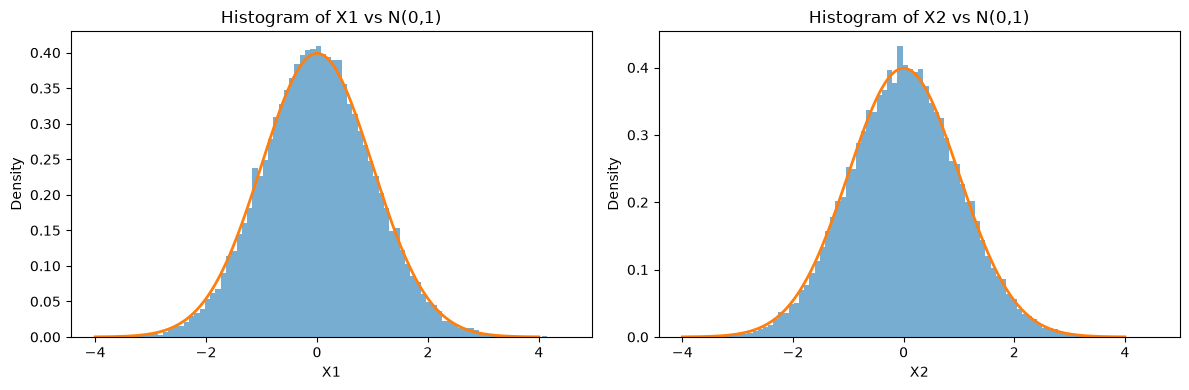

In [6]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(path[:, 0], bins=90, density=True, alpha=0.6)
plt.plot(xx, dnorm, lw=2)
plt.title("Histogram of X1 vs N(0,1)")
plt.xlabel("X1")
plt.ylabel("Density")

plt.subplot(1, 2, 2)
plt.hist(path[:, 1], bins=90, density=True, alpha=0.6)
plt.plot(xx, dnorm, lw=2)
plt.title("Histogram of X2 vs N(0,1)")
plt.xlabel("X2")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

Now go back and change $\rho$ to a value close to 1 (say $\rho = 0.9999$), then the marginal histograms will be quite far from standard normal densities. This shows that the Gibbs sampler has issues with variables that are highly correlated. 

## Example Two: Linear Regression


The second example is that of linear regression. The model is $y = X \beta + \epsilon$ with $\epsilon \sim N(0, \sigma^2 I_n)$ with $\beta_j, \log \sigma$ being uniform on $(-\infty, \infty)$.

For illustration, we use the heights dataset. 

In [7]:
import pandas as pd
height = pd.read_csv("PearsonHeightData.txt", sep = r"\s+")
print(height)

      Father   Son
0       65.0  59.8
1       63.3  63.2
2       65.0  63.3
3       65.8  62.8
4       61.1  64.3
...      ...   ...
1073    67.0  70.8
1074    71.3  68.3
1075    71.8  69.3
1076    70.7  69.3
1077    70.3  67.0

[1078 rows x 2 columns]


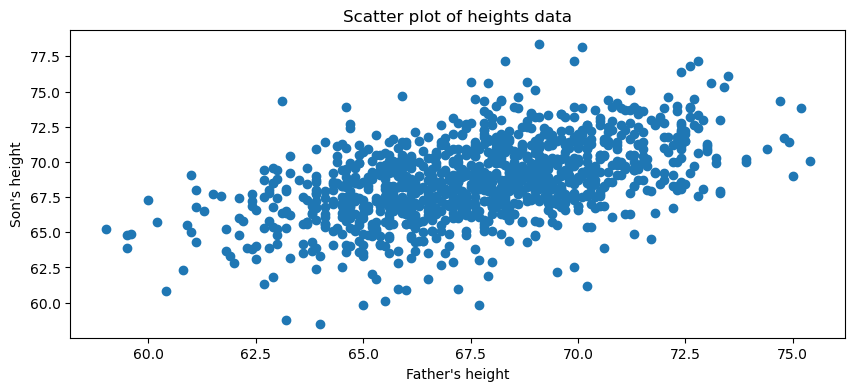

In [ ]:
plt.figure(figsize = (10, 4))
plt.scatter(height["Father"], height["Son"])
plt.xlabel("Father's height")
plt.ylabel("Son's height")
plt.title("Scatter plot of heights data")
plt.show()

In [8]:
n = height.shape[0]
X = np.column_stack([np.ones(n), height["Father"]]) #this is the X matrix (consisting of covariates and the column of ones)
y = height["Son"] #this is the y vector consisting of response values


The usual method of linear regression simply uses the OLS function in statsmodels. 

In [9]:
import statsmodels.api as sm
linmod = sm.OLS(y, X).fit()
print(linmod.summary())


                            OLS Regression Results                            
Dep. Variable:                    Son   R-squared:                       0.251
Model:                            OLS   Adj. R-squared:                  0.250
Method:                 Least Squares   F-statistic:                     360.9
Date:                Mon, 13 Jul 2026   Prob (F-statistic):           1.27e-69
Time:                        15:36:21   Log-Likelihood:                -2489.4
No. Observations:                1078   AIC:                             4983.
Df Residuals:                    1076   BIC:                             4993.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         33.8928      1.833     18.491      0.0

The estimate of $\sigma$ is obtained as follows.

In [11]:
bhat = linmod.params.values
print(bhat)
Sbhat = np.sum(linmod.resid ** 2)
m = X.shape[1] - 1 #in this case, m = 1
sighat = np.sqrt(Sbhat/(n-m-1)) #this is also called the residual standard error
print(sighat)

[33.89280054  0.51400591]
2.438134379352427


The Gibbs sampler for linear regression is implemented below. It is based on the following full conditionals: 
\begin{align*} 
   \beta \mid \sigma, \text{data} \sim N_p \left(\hat{\beta}, \sigma^2 (X^T X)^{-1} \right)
\end{align*}
where $\hat{\beta}$ is the least squares estimate, and
\begin{align*}
    \frac{1}{\sigma^2} \mid \beta, \text{data} \sim \text{Gamma} \left(\frac{n}{2}, \frac{1}{2} \|y - X \beta\|^2 \right). 
\end{align*}
So the Gibbs sampler algorithm is: 
   1. Initialize at arbitrary $\beta^{(0)}$ and $\sigma^{(0)}$.
   2. Repeat the following for $t = 1, \dots, N$. Pick $J$ to be either $1$ or $2$ with equal probability. If $J =1$, take $\beta^{(t+1)} \sim N_p(\hat{\beta}, (\sigma^{(t)})^2 (X' X)^{-1})$ and $\sigma^{(t+1)} = \sigma^{(t)}$. If $J = 2$, take $\beta^{(t+1)} = \beta^{(t)}$. Generate an observation $x$ from the Gamma distribution with parameters $n/2$ and $\|y - X\beta^{(t)}\|^2/2$. Then take $\sigma^{(t+1)} = x^{-1/2}$. 

This algorithm is implemented below. 

In [12]:
MM = np.linalg.inv(X.T @ X)

state = np.array([-30.0, 15.0, 250.0])   # bad initial value; still works
nit = 100000
path = np.zeros((nit, 3))
path[0] = state

for t in range(1, nit):
    j = np.random.randint(2)

    if j == 0:
        Cov_mat = (state[2] ** 2) * MM
        path[t, :2] = np.random.multivariate_normal(mean=bhat, cov=Cov_mat)
        path[t, 2] = state[2]

    else:
        path[t, :2] = state[:2]
        rss = np.sum((y - state[0] - state[1] * height["Father"]) ** 2)
        gg = np.random.gamma(shape=n / 2, scale=2 / rss)
        path[t, 2] = gg ** (-0.5)

    state = path[t]

    if (t + 1) % 2000 == 0:
        print(t + 1)


2000
4000
6000
8000
10000
12000
14000
16000
18000
20000
22000
24000
26000
28000
30000
32000
34000
36000
38000
40000
42000
44000
46000
48000
50000
52000
54000
56000
58000
60000
62000
64000
66000
68000
70000
72000
74000
76000
78000
80000
82000
84000
86000
88000
90000
92000
94000
96000
98000
100000


Below we plot the histograms of the posterior samples (after removing burnin of 500) along with the actual marginal posterior densities (which are t-densities for $\beta_0$ and $\beta_1$, and chi-squared for $RSS/\sigma^2$ where $RSS$ denotes the residual sum of squares).

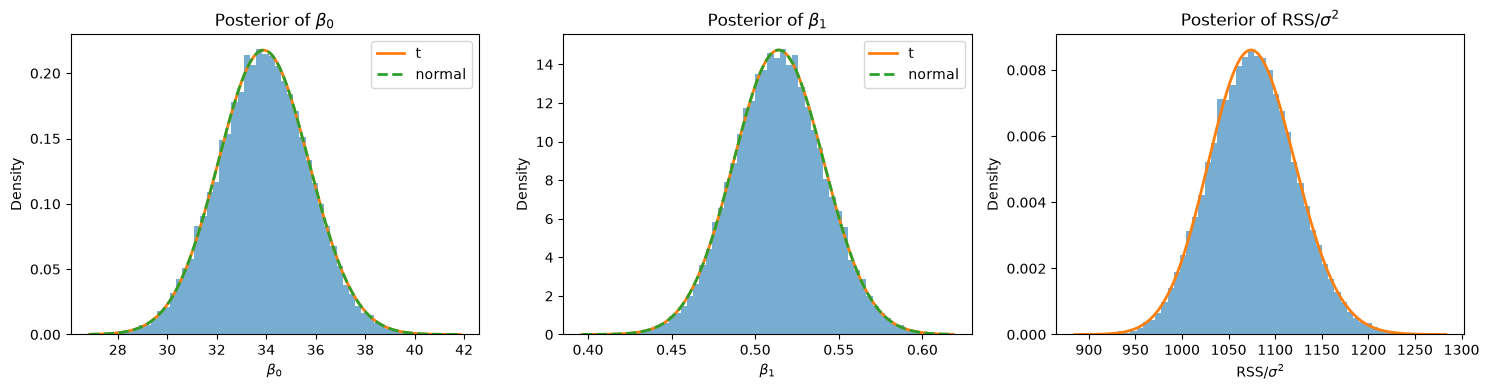

In [13]:
from scipy.stats import t, chi2, norm

df = n - 2
path2 = path[500:, :]

z_samp = Sbhat / (path2[:, 2] ** 2)

scale_beta0 = sighat * np.sqrt(MM[0, 0])
scale_beta1 = sighat * np.sqrt(MM[1, 1])

x0 = np.linspace(path2[:, 0].min(), path2[:, 0].max(), 400)
x1 = np.linspace(path2[:, 1].min(), path2[:, 1].max(), 400)
xz = np.linspace(max(1e-6, z_samp.min()), z_samp.max(), 400)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(path2[:, 0], bins=60, density=True, alpha=0.6)
plt.plot(x0, t.pdf(x0, df=df, loc=bhat[0], scale=scale_beta0), lw=2, label="t")
plt.plot(x0, norm.pdf(x0, loc=bhat[0], scale=scale_beta0), lw=2, ls="--", label="normal")
plt.title(r"Posterior of $\beta_0$")
plt.xlabel(r"$\beta_0$")
plt.ylabel("Density")
plt.legend()

plt.subplot(1, 3, 2)
plt.hist(path2[:, 1], bins=60, density=True, alpha=0.6)
plt.plot(x1, t.pdf(x1, df=df, loc=bhat[1], scale=scale_beta1), lw=2, label="t")
plt.plot(x1, norm.pdf(x1, loc=bhat[1], scale=scale_beta1), lw=2, ls="--", label="normal")
plt.title(r"Posterior of $\beta_1$")
plt.xlabel(r"$\beta_1$")
plt.ylabel("Density")
plt.legend()

plt.subplot(1, 3, 3)
plt.hist(z_samp, bins=60, density=True, alpha=0.6)
plt.plot(xz, chi2.pdf(xz, df=df), lw=2)
plt.title(r"Posterior of RSS/$\sigma^2$")
plt.xlabel(r"RSS/$\sigma^2$")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

From the above plots, it is clear that the Gibbs sampler is working well. 

## Example Three: Probit Regression

Consider the frogs dataset that we previously used for logistic regression. Below we fit the probit model to this data, using a standard software function. We fit both the probit model as well as the logistic regression model. Note that the fitted coefficients in both these models are somewhat close to each other. 

In [15]:
frogs = pd.read_csv("frogs.csv")

# Design matrix
X = frogs[['altitude','distance','NoOfPools','NoOfSites','avrain','meanmin','meanmax']].copy()
X['distance'] = np.log(X['distance'])
X['NoOfPools'] = np.log(X['NoOfPools'])
X = sm.add_constant(X)
y = frogs['pres.abs'].values

Xm = X.values
n, p = Xm.shape
linmod_cov = np.linalg.inv(Xm.T @ Xm)

# GLM (probit + logit)
print(sm.GLM(y, Xm, family=sm.families.Binomial(link=sm.families.links.Probit())).fit().summary())
print(sm.GLM(y, Xm, family=sm.families.Binomial()).fit().summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  212
Model:                            GLM   Df Residuals:                      204
Model Family:                Binomial   Df Model:                            7
Link Function:                 Probit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -99.536
Date:                Mon, 13 Jul 2026   Deviance:                       199.07
Time:                        15:37:48   Pearson chi2:                     229.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3173
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         40.9617     73.193      0.560      0.5

In the next code, we shall see how to perform Bayesian inference in this model (with the uniform prior on $\beta$) using the Gibbs sampler. 